# Actividad 16 – Detección de rostros en imagen

**Objetivo**: usar clasificadores Haar Cascade para detectar rostros.

En esta actividad vamos a:
1. Cargar una imagen
2. Cargar el clasificador Haar para detección de rostros
3. Detectar rostros en la imagen
4. Dibujar rectángulos alrededor de los rostros
5. Añadir texto "Rostro detectado"
6. Guardar el resultado

## 1. Importar librerías necesarias

In [23]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Configurar matplotlib para mostrar imágenes en el notebook
%matplotlib inline

## 2. Cargar imagen y convertir a escala de grises

✓ Imagen cargada correctamente
  Dimensiones: (408, 612, 3)
✓ Imagen convertida a escala de grises


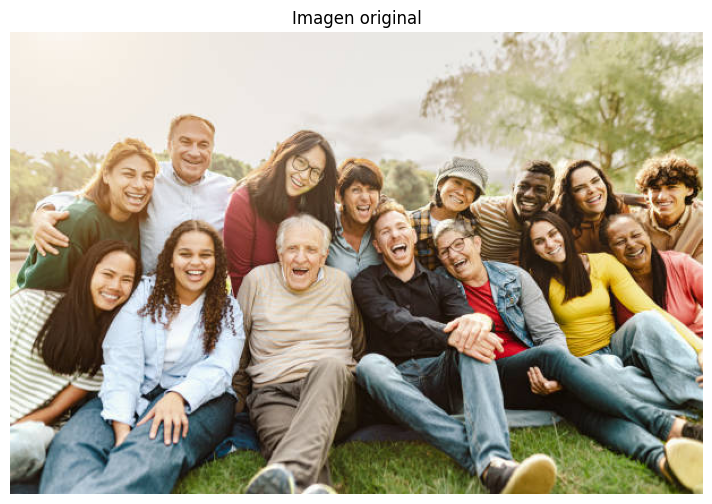

In [24]:
# Cargar la imagen
imagen = cv2.imread('imagen.jpg')

# Verificar que la imagen se cargó correctamente
if imagen is None:
    print("Error: No se pudo cargar la imagen. Verifica la ruta del archivo.")
else:
    print("✓ Imagen cargada correctamente")
    print(f"  Dimensiones: {imagen.shape}")
    
    # Convertir a escala de grises (requerido para Haar Cascade)
    imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    print("✓ Imagen convertida a escala de grises")
    
    # Convertir BGR a RGB para visualización
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(imagen_rgb)
    plt.title('Imagen original')
    plt.axis('off')
    plt.show()

## 3. Cargar clasificador Haar Cascade

OpenCV incluye clasificadores preentrenados para detección de rostros, ojos, sonrisas, etc.

In [25]:
# Cargar el clasificador Haar para detección de rostros frontales
# El archivo XML viene incluido con OpenCV
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Verificar que el clasificador se cargó correctamente
if face_cascade.empty():
    print("Error: No se pudo cargar el clasificador Haar Cascade")
else:
    print("✓ Clasificador Haar Cascade cargado correctamente")
    print(f"  Archivo: haarcascade_frontalface_default.xml")
    print(f"  Ubicación: {cv2.data.haarcascades}")

✓ Clasificador Haar Cascade cargado correctamente
  Archivo: haarcascade_frontalface_default.xml
  Ubicación: c:\Users\ampr2\Documents\FormacionProfesionalCFGS\IABD\PIA\venv_tf_gpu\lib\site-packages\cv2\data\


## 4. Detectar rostros en la imagen

El método detectMultiScale busca objetos (rostros) en diferentes escalas.

In [26]:
# Detectar rostros en la imagen
# Parámetros:
# - scaleFactor: qué tanto se reduce la imagen en cada escala (1.1 = 10% de reducción)
# - minNeighbors: cuántos vecinos debe tener cada rectángulo para ser considerado rostro
# - minSize: tamaño mínimo del rostro a detectar
rostros = face_cascade.detectMultiScale(
    imagen_gris,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print(f"✓ Detección completada")
print(f"  Rostros detectados: {len(rostros)}")

if len(rostros) > 0:
    print(f"\n  Detalles de cada rostro:")
    for i, (x, y, w, h) in enumerate(rostros, 1):
        print(f"  Rostro {i}: x={x}, y={y}, ancho={w}, alto={h}")

✓ Detección completada
  Rostros detectados: 7

  Detalles de cada rostro:
  Rostro 1: x=232, y=171, ancho=52, alto=52
  Rostro 2: x=138, y=79, ancho=49, alto=49
  Rostro 3: x=138, y=176, ancho=51, alto=51
  Rostro 4: x=292, y=125, ancho=39, alto=39
  Rostro 5: x=69, y=196, ancho=49, alto=49
  Rostro 6: x=86, y=107, ancho=49, alto=49
  Rostro 7: x=319, y=156, ancho=43, alto=43


## 5. Dibujar rectángulos y añadir texto

Marcamos cada rostro detectado con un rectángulo verde y texto.

✓ Rectángulos y texto añadidos
  Total de rostros marcados: 7


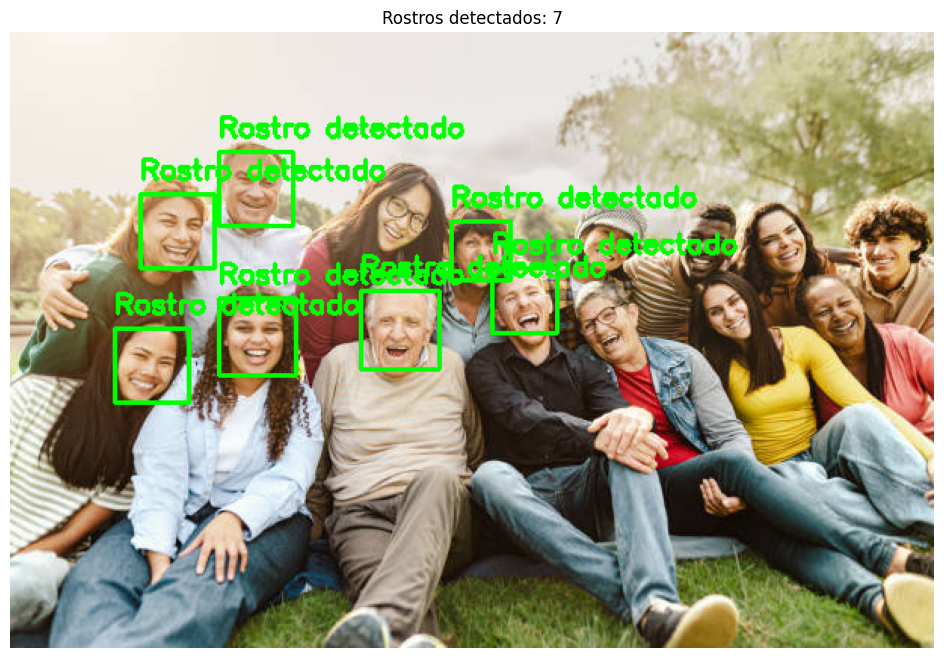

In [27]:
# Crear una copia de la imagen para dibujar
imagen_resultado = imagen.copy()

# Dibujar rectángulo y texto para cada rostro detectado
for i, (x, y, w, h) in enumerate(rostros, 1):
    # Dibujar rectángulo verde alrededor del rostro
    cv2.rectangle(imagen_resultado, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    # Añadir texto "Rostro detectado" encima del rectángulo
    texto = f"Rostro detectado"
    cv2.putText(imagen_resultado, texto, (x, y-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

print(f"✓ Rectángulos y texto añadidos")
print(f"  Total de rostros marcados: {len(rostros)}")

# Convertir a RGB para visualización
imagen_resultado_rgb = cv2.cvtColor(imagen_resultado, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(imagen_resultado_rgb)
plt.title(f'Rostros detectados: {len(rostros)}')
plt.axis('off')
plt.show()

## 6. Guardar resultado

✓ Imagen guardada como 'rostros_detectados.jpg'
  Rostros marcados: 7


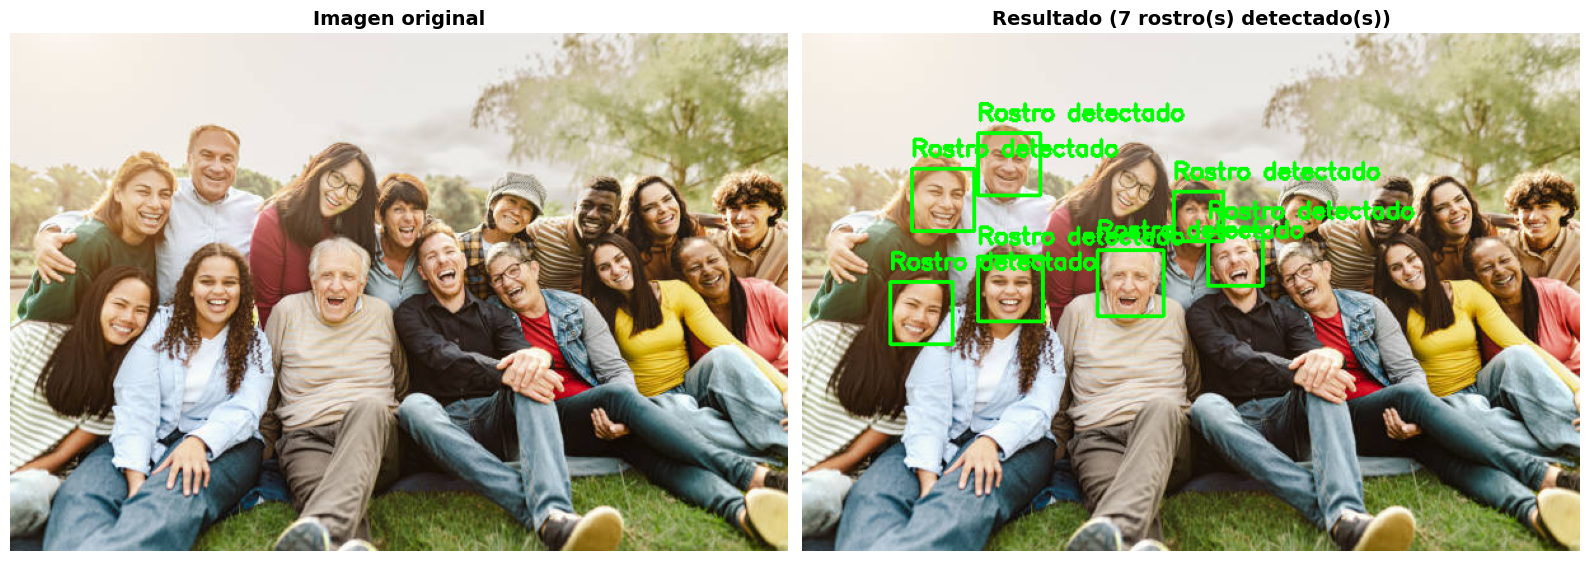


RESUMEN DE DETECCIÓN
Clasificador: Haar Cascade (frontalface)
Rostros detectados: 7
Archivo guardado: rostros_detectados.jpg


In [28]:
# Guardar la imagen con rostros detectados
nombre_salida = 'rostros_detectados.jpg'
cv2.imwrite(nombre_salida, imagen_resultado)

print(f"✓ Imagen guardada como '{nombre_salida}'")
print(f"  Rostros marcados: {len(rostros)}")

# Comparación antes y después
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(imagen_rgb)
axes[0].set_title('Imagen original', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(imagen_resultado_rgb)
axes[1].set_title(f'Resultado ({len(rostros)} rostro(s) detectado(s))', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RESUMEN DE DETECCIÓN")
print("="*60)
print(f"Clasificador: Haar Cascade (frontalface)")
print(f"Rostros detectados: {len(rostros)}")
print(f"Archivo guardado: {nombre_salida}")
print("="*60)